In [1]:
from google.colab import files

# PCからkaggle.jsonをアップロード
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
import os
import pandas as pd

# 1. Kaggle APIの認証用フォルダを作成し、ファイルを移動
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
# セキュリティのため、ファイルの所有者だけが読み書きできるように権限を変更
!chmod 600 ~/.kaggle/kaggle.json

# 2. 医療費データセット（Medical Cost Personal Datasets）をダウンロード
!kaggle datasets download -d mirichoi0218/insurance

# 3. ダウンロードしたZIPファイルを解凍
!unzip -o insurance.zip

# 4. Pandasのデータフレームとして読み込み
df = pd.read_csv('insurance.csv')

# 5. データのサイズ（行数、列数）を確認
print(f"データの形状 (行数, 列数): {df.shape}\n")

# 6. 先頭の5行を表示して中身を確認
df.head()

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 28.9MB/s]

Archive:  insurance.zip
  inflating: insurance.csv           
データの形状 (行数, 列数): (1338, 7)



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. カテゴリ変数（性別、喫煙の有無、地域）を 0 と 1 に変換
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# 変換後のデータを確認
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


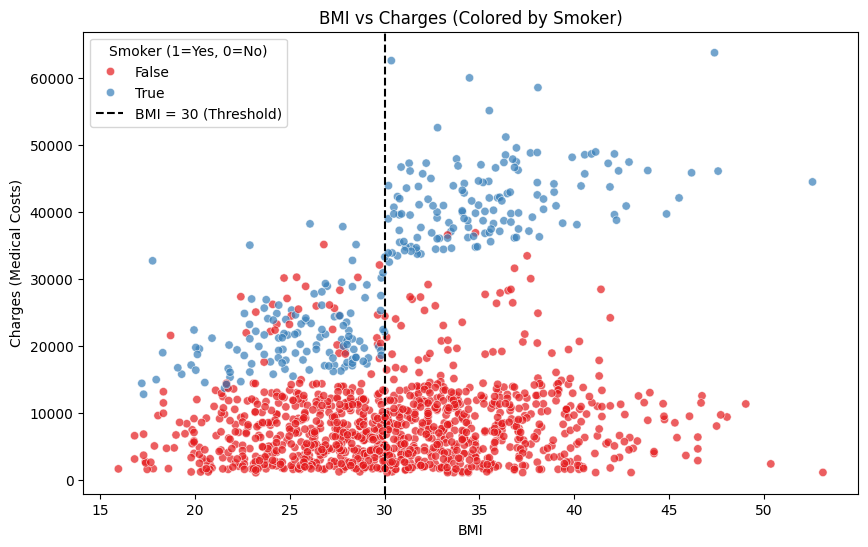

In [5]:
# 2. BMIと医療費の散布図を描画（喫煙の有無で色分け）
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker_yes', data=df_encoded, palette='Set1', alpha=0.7)

# グラフの装飾
plt.title('BMI vs Charges (Colored by Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges (Medical Costs)')
plt.axvline(x=30, color='black', linestyle='--', label='BMI = 30 (Threshold)') # 補助線
plt.legend(title='Smoker (1=Yes, 0=No)')
plt.show()

In [8]:
# 3. 「BMI30以上」かつ「喫煙者」を新しい特徴量にする
df_encoded['high_bmi_and_smoker'] = ((df_encoded['bmi'] >= 30) & (df_encoded['smoker_yes'] == 1)).astype(int)

df_encoded[['bmi', 'smoker_yes', 'high_bmi_and_smoker', 'charges']].head(20)

,bmi,smoker_yes,high_bmi_and_smoker,charges
0,27.900,True,0,16884.92400
1,33.770,False,0,1725.55230
2,33.000,False,0,4449.46200
3,22.705,False,0,21984.47061
4,28.880,False,0,3866.85520
5,25.740,False,0,3756.62160
6,33.440,False,0,8240.58960
7,27.740,False,0,7281.50560
8,29.830,False,0,6406.41070
9,25.840,False,0,28923.13692


In [9]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. 基礎となるカテゴリ変数の数値化
df_features = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# 2. 特徴量エンジニアリング
# 喫煙者 × 肥満 (BMI30以上)
df_features['high_bmi_smoker'] = ((df_features['bmi'] >= 30) & (df_features['smoker_yes'] == 1)).astype(int)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. 特徴量(X)と目的変数(y)の分割
X = df_features.drop(columns=['charges'])
y = df_features['charges']

# 2. データを学習用(Train)とテスト用(Test)に分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 線形回帰モデルの初期化と学習
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# 4. 学習したモデルを使って、テストデータの医療費を予測
y_pred = model_lr.predict(X_test)

# 5. モデルの精度評価
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("【モデルの予測精度】")
print(f"RMSE (平均誤差): {rmse:,.0f} ドル")
print(f"R2 Score (決定係数): {r2:.4f}\n")

# 6. 回帰係数の確認
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_lr.coef_})
# 影響度が大きい順に並び替え
print("【各特徴量の影響度（回帰係数）】")
print(coef_df.sort_values(by='Coefficient', ascending=False).round(1))

【モデルの予測精度】
RMSE (平均誤差): 4,458 ドル
R2 Score (決定係数): 0.8720

【各特徴量の影響度（回帰係数）】
            Feature  Coefficient
8   high_bmi_smoker      19850.7
4        smoker_yes      13292.2
2          children        469.8
0               age        261.8
1               bmi         56.6
5  region_northwest       -339.0
3          sex_male       -502.4
6  region_southeast       -692.2
7  region_southwest      -1371.8


In [11]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. 探索するハイパーパラメータの範囲を設定
param_grid_ridge_lasso = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
param_grid_elastic = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'l1_ratio': [0.2, 0.5, 0.8]
}

# 2. 各モデルの初期化
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42, max_iter=10000)
elastic = ElasticNet(random_state=42, max_iter=10000)

# 3. グリッドサーチの設定（5分割交差検証: cv=5）
grid_ridge = GridSearchCV(ridge, param_grid_ridge_lasso, cv=5, scoring='neg_mean_squared_error')
grid_lasso = GridSearchCV(lasso, param_grid_ridge_lasso, cv=5, scoring='neg_mean_squared_error')
grid_elastic = GridSearchCV(elastic, param_grid_elastic, cv=5, scoring='neg_mean_squared_error')

# 4. 学習と最適なパラメータの探索
grid_ridge.fit(X_train, y_train)
grid_lasso.fit(X_train, y_train)
grid_elastic.fit(X_train, y_train)

# 5. 各モデルの最良モデルを使ってテストデータを予測・評価
results = []
models = {
    'Ridge': grid_ridge,
    'Lasso': grid_lasso,
    'ElasticNet': grid_elastic
}

for name, grid in models.items():
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'RMSE (ドル)': round(rmse),
        'R2 Score': round(r2, 4)
    })

# 6. 結果をデータフレームにまとめて綺麗に表示
results_df = pd.DataFrame(results)
print("【正則化モデルの結果】")
print(results_df.to_string(index=False))

【正則化モデルの結果】
     Model                      Best Params  RMSE (ドル)  R2 Score
     Ridge                   {'alpha': 1.0}       4455    0.8722
     Lasso                   {'alpha': 1.0}       4458    0.8720
ElasticNet {'alpha': 0.01, 'l1_ratio': 0.8}       4452    0.8723


In [15]:
!pip install optuna
import numpy as np
import optuna
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. 目的関数の定義
def objective(trial):
    # 探索するパラメータの範囲を指定
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
    }

    # モデルの定義
    rf = RandomForestRegressor(**params, n_jobs=-1)

    # 5分割交差検証による評価
    scores = cross_val_score(
        rf, X_train, y_train, cv=5, scoring="neg_mean_squared_error", n_jobs=-1
    )
    rmse = np.sqrt(-scores.mean())

    return rmse


# 2. 最適化セッションの作成と実行
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

# 3. 最良パラメータを用いた最終モデルの評価
best_params = study.best_value
print("【Optunaによる最適化結果】")
print(f"Best Trial (最小RMSE): {study.best_value:,.0f} ドル")
print(f"Best Params (最適パラメータ): {study.best_params}\n")

# 最良のパラメータでテストデータに対する予測精度を検証
best_rf_optuna = RandomForestRegressor(**study.best_params, random_state=42)
best_rf_optuna.fit(X_train, y_train)
y_pred_optuna = best_rf_optuna.predict(X_test)

rmse_optuna = np.sqrt(mean_squared_error(y_test, y_pred_optuna))
r2_optuna = r2_score(y_test, y_pred_optuna)

print("【テストデータに対する予測精度】")
print(f"RMSE (平均誤差): {rmse_optuna:,.0f} ドル")
print(f"R2 Score (決定係数): {r2_optuna:.4f}\n")

# 4. 特徴量重要度の確認
importances = best_rf_optuna.feature_importances_
importances_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
print("【特徴量重要度】")
print(
    importances_df.sort_values(by="Importance", ascending=False).to_string(
        index=False
    )
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.7 MB/s eta 0:00:00
【Optunaによる最適化結果】
Best Trial (最小RMSE): 4,617 ドル
Best Params (最適パラメータ): {'n_estimators': 189, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}

【テストデータに対する予測精度】
RMSE (平均誤差): 4,486 ドル
R2 Score (決定係数): 0.8703

【特徴量重要度】
         Feature  Importance
 high_bmi_smoker    0.437428
      smoker_yes    0.367876
             age    0.105720
             bmi    0.066231
        children    0.011505
        sex_male    0.003741
region_southeast    0.002828
region_southwest    0.002540
region_northwest    0.002131


In [16]:
import warnings
import lightgbm as lgb
import numpy as np
import optuna
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# 1. 目的関数の定義
def objective(trial):
    # LightGBMの主要なハイパーパラメータの探索範囲を設定
    params = {
        "objective": "regression",
        "metric": "rmse",
        "random_state": 42,
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "verbose": -1,
    }

    model = lgb.LGBMRegressor(**params)

    # 5分割交差検証による評価
    scores = cross_val_score(
        model, X_train, y_train, cv=5, scoring="neg_mean_squared_error", n_jobs=-1
    )
    rmse = np.sqrt(-scores.mean())

    return rmse


# 2. 最適化セッションの作成と実行
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print("【OptunaによるLightGBM最適化結果】")
print(f"Best Trial (最小CV-RMSE): {study.best_value:,.0f} ドル")
print(f"Best Params: {study.best_params}\n")

# 3. 最良パラメータを用いた最終モデルの学習とテストデータ評価
best_lgb = lgb.LGBMRegressor(
    **study.best_params, importance_type="gain", random_state=42, verbose=-1
)
best_lgb.fit(X_train, y_train)
y_pred_lgb = best_lgb.predict(X_test)

rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb = r2_score(y_test, y_pred_lgb)

print("【テストデータに対する予測精度（LightGBM）】")
print(f"RMSE (平均誤差): {rmse_lgb:,.0f} ドル")
print(f"R2 Score (決定係数): {r2_lgb:.4f}\n")

# 4. 特徴量重要度の抽出
importances = best_lgb.feature_importances_
importances_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})

print("【特徴量重要度（ゲイン基準）】")
print(
    importances_df.sort_values(by="Importance", ascending=False).to_string(
        index=False
    )
)

【OptunaによるLightGBM最適化結果】
Best Trial (最小CV-RMSE): 4,550 ドル
Best Params: {'n_estimators': 290, 'learning_rate': 0.014644189140622217, 'num_leaves': 17, 'max_depth': 3, 'min_child_samples': 30, 'subsample': 0.8774148981676134, 'colsample_bytree': 0.9972061549714198}

【テストデータに対する予測精度（LightGBM）】
RMSE (平均誤差): 4,397 ドル
R2 Score (決定係数): 0.8754

【特徴量重要度（ゲイン基準）】
         Feature   Importance
 high_bmi_smoker 3.414480e+12
      smoker_yes 5.997789e+11
             age 5.417693e+11
             bmi 4.689685e+10
        children 2.848160e+10
region_southwest 4.824830e+09
        sex_male 1.329253e+09
region_southeast 5.226702e+08
region_northwest 0.000000e+00
